# Lecture : Shallow Graph Learning

## Lab 03 : Graph Classification with Weisfeiler–Lehman Kernel -- Solution

### Xavier Bresson


In this notebook we classify the 8 graph classes of DGL's `MiniGCDataset` using the **Weisfeiler–Lehman (1-WL) kernel**.

The graphs in `MiniGCDataset` do not have semantic node labels, so every node starts with the same color label:

$$
c_0(v)=0, \ \forall v \in V.
$$

At the WL iteration $t$, each node $v$ is relabeled from its current color label and the multiset of color labels in its one-hop neighborhood:

$$
c_t(v)
=
\operatorname{HASH}
\left(
c_{t-1}(v),
\{c_{t-1}(u):u\in N(v)\}
\right)\in\mathbb{R},
$$

where $\operatorname{HASH}$ is an injective function that takes as input a node's current color and the multiset of its neighbors' colors, and outputs a new color label. Thus, two nodes receive the same new color if and only if these two signatures are identical.

For each iteration $t=0,\ldots,T$, we count how many nodes receive each WL label. Concatenating these histograms gives a graph-level feature vector:

$$
\phi_T(G)
=
[c_0(G),c_1(G),\ldots,c_T(G)]^\top\in\mathbb{R}^T.
$$

The **WL kernel** is the normalized inner product:

$$
K_T(G,G')
=
\frac{\phi_T(G)^\top \phi_T(G')}
{\|\phi_T(G)\|_2\,\|\phi_T(G')\|_2}
\in[0,1]
$$

and train a kernel SVM model.


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/05_Shallow_Learning'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip -q install dgl==1.0.2 # install DGL library


In [2]:
from collections import Counter
import hashlib
import time
import dgl
from dgl.data import MiniGCDataset
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

CLASS_NAMES = [
    "cycle",
    "star",
    "wheel",
    "lollipop",
    "hypercube",
    "grid",
    "clique",
    "circular ladder",
]

WL_T = 3 # WL_T = T is the number of WL refinement iterations. 


## Step 1 : Generate and visualize the 8 graph classes


Number of graphs: 640
Graphs per class: [80 80 80 80 80 80 80 80]


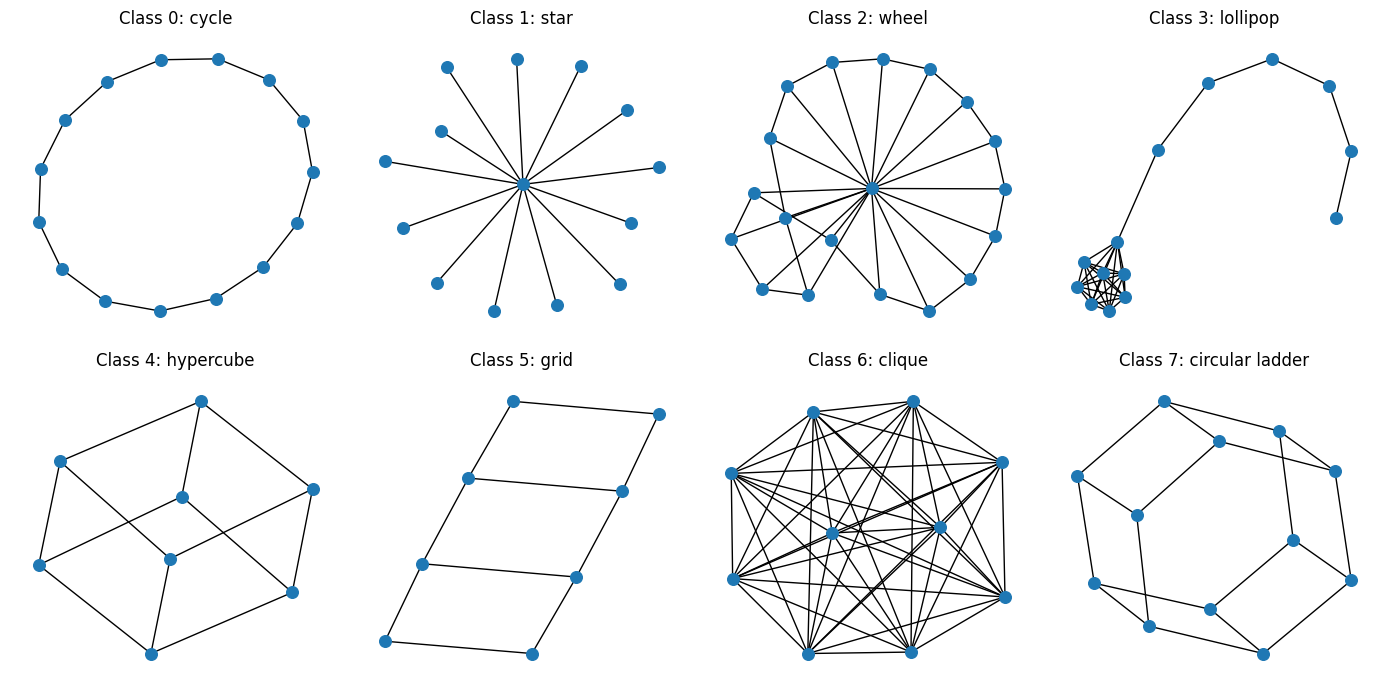

In [3]:
# Generate a dataset of 640 graphs, with random size between 10 and 20 nodes
dataset = MiniGCDataset(640, 10, 20)
# print('dataset:', dataset)
labels = np.array([int(dataset[i][1]) for i in range(len(dataset))]) # labels = [0 .. 0, 1 .. 1, .. , 7 .. 7]
# print('labels.shape:', labels.shape, labels) # (640,)
print("Number of graphs:", len(dataset)) # 640
print("Graphs per class:", np.bincount(labels)) # [80 80 80 80 80 80 80 80]

def dgl_to_simple_nx(g):
    G = nx.Graph(g.to_networkx())
    G.remove_edges_from(nx.selfloop_edges(G)) # MiniGCDataset adds self-loops.
                                              # WL is applied to the underlying simple undirected graph.
    return nx.convert_node_labels_to_integers(G)

# Convert DGL graphs once and reuse them throughout the notebook
graphs = [dgl_to_simple_nx(dataset[i][0]) for i in range(len(dataset))]

# Visualize one example from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for c, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(labels == c)[0]
    G = graphs[idx]
    nx.draw(G, ax=ax, node_size=70, width=1.0)
    ax.set_title(f"Class {c}: {CLASS_NAMES[c]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step 2 : Define the Weisfeiler–Lehman coloring function

The 1-WL procedure starts with one discrete label per node. Since the graphs in `MiniGCDataset` have no semantic node labels, every node starts from the same label:

$$
c_0(v)=0, \ \forall v \in V.
$$

At every iteration $t$, the new label of node $v$ depends on

1. its current label $c_{t-1}(v)$, and
2. the multiset $\{c_{t-1}(u):u\in N(v)\}$ of current labels of its neighbors.
   
Because this is a multiset, the neighborhood representation is inherently permutation-invariant. 

However, in our implementation, we **sort** the neighbor labels only to obtain a canonical serialization of the multiset before applying the deterministic hash. The same signature must receive the same label in every graph. For example, we want the same output for ["red", "blue", "red"] and ["red", "red", "blue"].

Here, we use a deterministic BLAKE2 hash function.


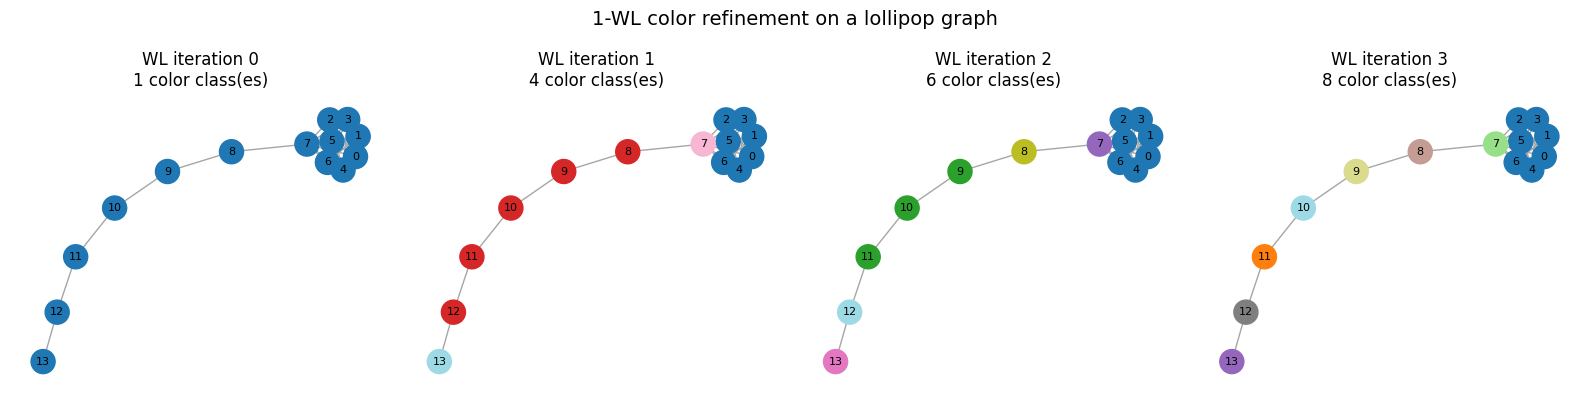

In [4]:
# HASH coloring function using BLAKE2
def wl_hash(current_color, neighbor_colors):
    signature = repr((current_color, tuple(sorted(neighbor_colors)))).encode("utf-8")
    return hashlib.blake2b(signature, digest_size=16).hexdigest()

# Visualize the 1-WL coloring process on a lollipop graph
#
# All nodes start with the same color at iteration 0. At each WL iteration,
# a node is recolored from its current color and the multiset of neighbor colors.
# The node positions are fixed across panels so only the coloring changes.
#
# For visualization, we make colors "inherit" across iterations whenever possible:
# If a color class continues without splitting, it keeps the same display color,
# If a class splits, one child keeps the parent color and new child classes get fresh display colors.

def build_inherited_visual_colorings(colorings):
    """
    Assign visual color IDs so that colors are preserved across successive WL
    iterations whenever a class continues. If a class splits, one child keeps
    the parent color and the remaining children get new colors.
    """
    visual_colorings = []
    # Iteration 0: all labels get a fresh display color.
    next_color_id = 0
    first_labels = sorted(set(colorings[0].values()))
    prev_label_to_color = {label: i for i, label in enumerate(first_labels)}
    next_color_id = len(prev_label_to_color)
    visual_colorings.append({v: prev_label_to_color[label] for v, label in colorings[0].items()})
    # Later iterations: inherit colors from previous iteration when possible.
    for t in range(1, len(colorings)):
        prev_coloring = colorings[t - 1]
        curr_coloring = colorings[t]
        # For each previous WL label, collect the current WL labels reached by its nodes.
        children = {}
        for v in curr_coloring:
            parent_label = prev_coloring[v]
            child_label = curr_coloring[v]
            children.setdefault(parent_label, []).append(child_label)
        curr_label_to_color = {}
        for parent_label, child_labels in children.items():
            # Unique child labels, ordered by decreasing size then lexicographically.
            counts = {}
            for child_label in child_labels:
                counts[child_label] = counts.get(child_label, 0) + 1
            ordered_children = sorted(counts, key=lambda c: (-counts[c], c))
            # Let the largest child keep the parent's display color.
            curr_label_to_color[ordered_children[0]] = prev_label_to_color[parent_label]
            # Any additional children are new visual colors.
            for child_label in ordered_children[1:]:
                if child_label not in curr_label_to_color:
                    curr_label_to_color[child_label] = next_color_id
                    next_color_id += 1
        # Safety check: assign colors to any unexpected unseen labels.
        for child_label in set(curr_coloring.values()):
            if child_label not in curr_label_to_color:
                curr_label_to_color[child_label] = next_color_id
                next_color_id += 1
        visual_colorings.append({v: curr_label_to_color[label] for v, label in curr_coloring.items()})
        prev_label_to_color = curr_label_to_color
    return visual_colorings

# Select one lollipop graph (class 3)
demo_class = 3 # lollipop
demo_idx = np.flatnonzero(labels == demo_class)[0]
G_demo = graphs[demo_idx]

# Record node WL labels at iterations 0, ..., WL_T.
colorings = []
colors = {v: "0" for v in G_demo.nodes()}
colorings.append(colors.copy())
for _ in range(WL_T):
    colors = { v: wl_hash( colors[v], [colors[u] for u in G_demo.neighbors(v)] ) for v in G_demo.nodes() }
    colorings.append(colors.copy())

# Build inherited visual colors
visual_colorings = build_inherited_visual_colorings(colorings)

# Plot the WL coloring process
fig, axes = plt.subplots(1, WL_T + 1, figsize=(4 * (WL_T + 1), 4), squeeze=False)
axes = axes.ravel()
pos = nx.spring_layout(G_demo) # Fixed layout across all panels
for t, (ax, coloring, visual_coloring) in enumerate(zip(axes, colorings, visual_colorings)):
    node_colors = [visual_coloring[v] for v in G_demo.nodes()]
    n_classes = len(set(coloring.values()))
    nx.draw_networkx(G_demo, pos=pos, ax=ax, node_color=node_colors, cmap=plt.cm.tab20, node_size=300, edge_color="0.65", with_labels=True, font_size=8)
    ax.set_title(f"WL iteration {t}\n{n_classes} color class(es)")
    ax.axis("off")
fig.suptitle(f"1-WL color refinement on a {CLASS_NAMES[demo_class]} graph", fontsize=14)
plt.tight_layout()
plt.show()


## Step 3 : Compute WL label histograms

For a graph $G$, we apply the WL refinement for $T$ iterations.

At each iteration $t$, we count how many nodes have each WL color label. Let

$$
h_t(G)_\ell = \left|\{v \in V : c_t(v) = \ell\}\right|
$$

be the number of nodes in graph $G$ having WL color label $\ell$ at iteration $t$, and let $h_t(G)$ denote the corresponding histogram of WL color labels.

For example, suppose that at some WL iteration the node color labels are

$$
[a,a,a,b,b,c].
$$

Then,

$$
h_t(G)_a=3,\qquad h_t(G)_b=2,\qquad h_t(G)_c=1.
$$

The histogram at $t=0$ contains only the initial color label. Because all nodes start with the same color, after the first WL refinement the color labels distinguish nodes according to their degrees.

The cost of one WL iteration is linear in the graph size: $O(|V|+|E|)$, so computing $T$ iterations costs $O\!\left(T(|V|+|E|)\right)$. Although in our implementation, the neighbor color labels are sorted before hashing.


In [5]:
# Compute WL label-count histogram for iterations 0,...,T
def wl_histogram(G, h=WL_T):
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    # MiniGCDataset is unlabeled: all nodes start with the same color.
    colors = {v: "0" for v in G.nodes()}
    histograms = [Counter(colors.values())]
    for _ in range(h):
        new_colors = {}
        for v in G.nodes():
            neighbor_colors = [colors[u] for u in G.neighbors(v)]
            new_colors[v] = wl_hash(colors[v], neighbor_colors)
        colors = new_colors
        histograms.append(Counter(colors.values()))
    return histograms

# Sanity check on one lollipop graph (class 3)
demo_class = 3 # lollipop
demo_idx = np.flatnonzero(labels == demo_class)[0]
G_demo = graphs[demo_idx]
_demo_hist = wl_histogram(G_demo, h=WL_T)
# Map WL hash labels to simple integer color IDs for display, e.g. '2b7fa95f658412e51046185159e47dc6' -> 1
label_to_color = {"0": 0}
next_color = 1
for hist in _demo_hist[1:]:
    for label in hist:
        if label not in label_to_color:
            label_to_color[label] = next_color
            next_color += 1
print("Example of a lollipop graph")
print(" number of nodes:", G_demo.number_of_nodes())
print(" distinct WL labels at each iteration:", [len(hist) for hist in _demo_hist])
for t in range(WL_T + 1):
    integer_hist = {label_to_color[label]: count for label, count in _demo_hist[t].items()}
    print(f" histogram at h={t}:", integer_hist)
    

Example of a lollipop graph
 number of nodes: 14
 distinct WL labels at each iteration: [1, 4, 6, 8]
 histogram at h=0: {0: 14}
 histogram at h=1: {1: 7, 2: 1, 3: 5, 4: 1}
 histogram at h=2: {5: 7, 6: 1, 7: 1, 8: 3, 9: 1, 10: 1}
 histogram at h=3: {11: 7, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1}


## Step 4 : Build the WL feature vector

At iteration $t$, let $\mathcal{L}_t$ denote the set of WL color labels. For each label $\ell\in\mathcal{L}_t$,

$$
h_t(G)_\ell
=
\left|\{v\in V:c_t(v)=\ell\}\right|
$$

counts the number of nodes in graph $G$ having color label $\ell$ at iteration $t$.

The WL feature vector is obtained by concatenating the label-count histograms from all iterations:

$$
\phi_T(G)
=
\begin{bmatrix}
h_0(G)\\
h_1(G)\\
\vdots\\
h_T(G)
\end{bmatrix}.
$$

Equivalently, each coordinate is indexed by a pair $(t,\ell)$:

$$
\phi_T(G)_{(t,\ell)}
=
\left|\{v\in V:c_t(v)=\ell\}\right|.
$$

Thus, each feature records how many nodes have a particular WL color label $\ell$ at a particular WL iteration $t$.

For example, suppose $h_0(G)=\begin{bmatrix}14\end{bmatrix}$, $\ h_1(G)=\begin{bmatrix}7\\5\\1\\1\end{bmatrix}\ $, and $h_2(G)=\begin{bmatrix}7\\3\\1\\1\\1\\1\end{bmatrix}$. Then, for $T=2$, we have $\phi_2(G)=\begin{bmatrix}14\\7\\5\\1\\1\\7\\3\\1\\1\\1\\1\end{bmatrix}$.


In [6]:
def wl_feature_dict(histograms):
    """
    Sparse dictionary representation of phi_h(G).
    Each key identifies both the WL iteration t and the discrete WL color label l.
    """
    features = {}
    for t, histogram in enumerate(histograms):
        for color, count in histogram.items():
            features[f"h{t}:{color}"] = float(count)
    return features

# Example WL histograms for one graph
histograms = [
    Counter({0: 14}),                              # h = 0
    Counter({1: 7, 2: 5, 3: 1, 4: 1}),             # h = 1
    Counter({5: 7, 6: 3, 7: 1, 8: 1, 9: 1, 10: 1}) # h = 2
]
features = wl_feature_dict(histograms)
print('features', features)


features {'h0:0': 14.0, 'h1:1': 7.0, 'h1:2': 5.0, 'h1:3': 1.0, 'h1:4': 1.0, 'h2:5': 7.0, 'h2:6': 3.0, 'h2:7': 1.0, 'h2:8': 1.0, 'h2:9': 1.0, 'h2:10': 1.0}


## Step 5 : Compute the WL representation for every graph

We use $T=3$ WL refinement iterations.

The resulting (sparse) feature matrix has shape $N_{\text{g}}\times d_h$, where $N_{\text{g}}$ is the number of graphs, and $d_h$ is the number of distinct WL color features observed across the dataset.

Unlike the 9-dim graphlet representation, the WL feature dimension is **data dependent** and usually grows with the refinement depth $T$.


In [7]:
# Compute WL histograms for all graphs
tic = time.time()
all_wl_histograms = [wl_histogram(G, h=WL_T) for G in graphs]
# print(all_wl_histograms[0]) # [Counter({'0': 15}), Counter({'9': 15}), Counter({'110': 15}), Counter({'226': 15})]
elapsed = time.time() - tic

# Convert the sparse dictionaries to one common feature space
feature_dicts = [wl_feature_dict(histograms) for histograms in all_wl_histograms]
# print(feature_dicts[0]) # {'h0:0': 15.0, 'h1:9': 15.0, 'h2:110': 15.0, 'h3:226': 15.0}
vectorizer = DictVectorizer(sparse=True, sort=True)
X_wl = vectorizer.fit_transform(feature_dicts)
# print(X_wl[0]) # (0, 0)	15.0
#                # (0, 9)	15.0
#                # (0, 110) 15.0
#                # (0, 226) 15.0
print(f"Computed WL features up to h={WL_T} in {elapsed:.2f} s")
print("WL feature matrix shape:", X_wl.shape) # (640, 285) -> 285 created colors

# Print how many distinct WL labels occur at each exact iteration t
rows = []
for t in range(WL_T + 1):
    labels_at_t = set()
    for histograms in all_wl_histograms: labels_at_t.update(histograms[t].keys())
    rows.append({"WL iteration t": t, "distinct WL labels l": len(labels_at_t)})
pd.DataFrame(rows)


Computed WL features up to h=3 in 0.08 s
WL feature matrix shape: (640, 285)


,WL iteration t,distinct WL labels l
0,0,1
1,1,18
2,2,104
3,3,162


## Step 6 : Build the Weisfeiler–Lehman kernel

The un-normalized WL kernel is

$$
K_T = X_T X_T^\top \in\mathbb{R}^{N_{\text{g}}\times N_{\text{g}}},
$$

where $X_T\in\mathbb{R}^{N_{\text{g}}\times d_h}$ contains the WL count vectors.

We then apply diagonal normalization:

$$
K_{ij}
\leftarrow 
\frac{K_{ij}}
{\sqrt{K_{ii}K_{jj}}} \in[0,1],
$$

so every non-zero graph has self-similarity 1.


WL kernel shape: (640, 640)
Diagonal min/max: 0.9999999999999998 1.0000000000000002
Matrix min/max: 0.25 1.0000000000000002


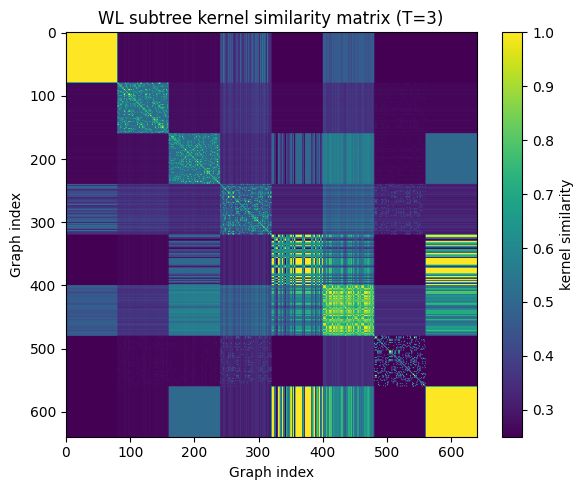

In [8]:
# Un-normalized WL kernel
K_wl_raw = (X_wl @ X_wl.T).toarray()

# Normalized WL kernel
def normalize_kernel(K, eps=1e-12):
    diag = np.sqrt(np.maximum(np.diag(K), eps))
    return K / np.outer(diag, diag)
K_wl = normalize_kernel(K_wl_raw)

print("WL kernel shape:", K_wl.shape)
print("Diagonal min/max:", np.diag(K_wl).min(), np.diag(K_wl).max()) # self-similarity
print("Matrix min/max:", K_wl.min(), K_wl.max())

# Visualize the kernel after sorting graphs by class.
order = np.argsort(labels)
K_sorted = K_wl[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(K_sorted, aspect="auto")
ax.set_title(f"WL subtree kernel similarity matrix (T={WL_T})")
ax.set_xlabel("Graph index")
ax.set_ylabel("Graph index")
fig.colorbar(im, ax=ax, label="kernel similarity")
plt.tight_layout()
plt.show()


## Step 7 : SVM classification with the Weisfeiler–Lehman kernel

We use a stratified train/test split, train an SVM with the Weisfeiler–Lehman kernel, and evaluate on the test set.


Split sizes:
 train: 512 [64 64 64 64 64 64 64 64]
 test:  128 [16 16 16 16 16 16 16 16]
Test accuracy: 0.914


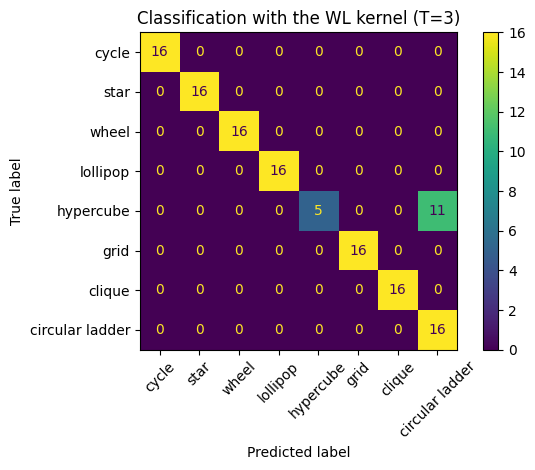

In [9]:
# Train / test split
indices = np.arange(len(dataset))
# 640 graphs -> 80/20 -> 512 train, 128 test
train_idx, test_idx = train_test_split(indices, test_size=128, stratify=labels)
print("Split sizes:")
print(" train:", len(train_idx), np.bincount(labels[train_idx]))
print(" test: ", len(test_idx), np.bincount(labels[test_idx]))

# Train an SVM using the WL kernel and evaluate on the test set
def classify_with_wl_kernel(K, y, train_idx, test_idx, C):
    K_train = K[np.ix_(train_idx, train_idx)]
    model = SVC(C=C, kernel="precomputed")
    model.fit(K_train, y[train_idx])
    test_pred = model.predict(K[np.ix_(test_idx, train_idx)])
    test_acc = accuracy_score(y[test_idx], test_pred)
    return test_acc, test_pred

test_acc, test_pred = classify_with_wl_kernel(K_wl, labels, train_idx, test_idx, 100)
print(f"Test accuracy: {test_acc:.3f}")

# Display the confusion matrix on the test set
ConfusionMatrixDisplay.from_predictions(labels[test_idx], test_pred, display_labels=CLASS_NAMES, xticks_rotation=45)
plt.title(f"Classification with the WL kernel (T={WL_T})")
plt.tight_layout()
plt.show()


## Remarks

- The WL kernel is a **multiscale** graph kernel: Iteration $t$ summarizes rooted neighborhood patterns at progressively larger scales.
- Because `MiniGCDataset` has no semantic node labels, all nodes start with one common label. The first WL refinement therefore separates nodes according to degree.
- The feature dimension is **data dependent** because every distinct pair `(WL-t, WL-l)` defines a coordinate.
- The parameter `WL_T` controls the largest neighborhood scale included in the representation. 
- The 1-WL kernel is efficient and good, but it is **not a complete graph-isomorphism test**: some non-isomorphic graphs cannot be distinguished by 1-WL kernel.
- How does the WL kernel compare with the graphlet kernel on this dataset?
